# 04 - Access windows

This is the question a satellite operation planning system exists to answer: **given a target on
the ground, when can we image it, and how good will the geometry be?**

A radar satellite cannot image whatever happens to be beneath it. It looks sideways, and it can
steer that sideways angle only within limits. So a target is reachable during short, separate
intervals - **access windows** - and everything else in planning follows from them. Which
satellite gets a request, whether two requests collide, whether a deadline can be met: all of it
is downstream of this computation.

**What this notebook does**

1. State the constraint - the range of off-nadir angles the radar can be steered through
2. Write the geometry test: at a given instant, can this satellite see this target?
3. Sweep a horizon for every satellite and every target, and refine the window edges
4. Draw the timeline an operator would actually read
5. Measure the work, because this is the part of the backend that has to be fast
6. Export fixtures so the Go implementation can be checked against these results

The result feeds directly into the Go `flightdyn-service`. This notebook is where the algorithm
gets settled and its answers recorded, before any of it is ported.

## Setup

In [1]:
from pathlib import Path
import json
import time
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sgp4.api import Satrec, jday

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'data').is_dir())
FIXTURES = ROOT / 'fixtures'

R_E   = 6378137.0
F_WGS = 1 / 298.257223563
E2    = F_WGS * (2 - F_WGS)
OMEGA = 7.292115e-5

tle_raw = (FIXTURES / 'tle_strix.txt').read_text()
lines = [l.rstrip() for l in tle_raw.strip().splitlines() if l.strip()]
TLES = {lines[i].strip(): (lines[i + 1], lines[i + 2]) for i in range(0, len(lines), 3)}
print(f'{len(TLES)} satellites loaded from the cached Celestrak TLEs')

8 satellites loaded from the cached Celestrak TLEs


## 1. The constraint

The radar is mounted looking to the side and can be steered through a range of **off-nadir
angles** - the tilt away from straight down. Both ends of that range are real limits.

Too close to straight down and the geometry collapses: a radar measures distance, so near nadir
the returns from either side of the track arrive at nearly the same time and cannot be separated.
Too far out and the beam is spread over too much ground at too shallow an angle, the signal has
further to travel, and the image gets noisy.

**What the manual does and does not say.** The Synspective SAR Data Product Format Manual is a
file format specification. It defines where the off-nadir angle is written in each product and
in what units, but it does not publish the spacecraft's steering envelope. So we cannot read the
limits out of it.

We therefore treat the range as an explicit assumption, not a fact. The one hard number we hold
is from our own scene: the delivered product was taken at **31.94 degrees** off-nadir, which sits
comfortably inside any plausible envelope. Anyone with the real figures changes two constants
below and every result updates.

In [2]:
# ASSUMPTION - not from the Format Manual. Replace with the real steering envelope when known.
OFF_NADIR_MIN = 20.0        # degrees
OFF_NADIR_MAX = 45.0        # degrees
OBSERVED_OFF_NADIR = 31.94  # the delivered StriX-3 product, for reference

TARGETS = {
    'Mt. Aso, JP':      (32.887635, 131.092252),   # the scene from notebooks 01-02
    'Tokyo, JP':        (35.6762, 139.6503),
    'Jakarta, ID':      (-6.2088, 106.8456),
    'Longyearbyen, NO': (78.2232, 15.6267),        # high Arctic
}

HORIZON_DAYS, COARSE_STEP_S = 3.0, 20

print(f'off-nadir window : {OFF_NADIR_MIN} to {OFF_NADIR_MAX} deg  (assumed)')
print(f'our scene        : {OBSERVED_OFF_NADIR} deg  (measured)')
print(f'{len(TARGETS)} targets x {len(TLES)} satellites over {HORIZON_DAYS:.0f} days')

off-nadir window : 20.0 to 45.0 deg  (assumed)
our scene        : 31.94 deg  (measured)
4 targets x 8 satellites over 3 days


## 2. Can this satellite see this target, right now?

The same frame handling as notebook 03 - SGP4 returns TEME, latitude and longitude live in ECEF,
and the velocity needs the rotating-frame term subtracted or every derived angle is wrong.

Given the satellite state and a target, the test is:

- **line of sight**, from the elevation of the satellite above the target's horizon. This has to
  come first, and it is easy to leave out. The off-nadir angle is not monotonic in distance: it
  rises as the target moves away, peaks near the horizon, then *falls again* for targets on the
  far side of the Earth. A constraint written on the angle alone therefore re-admits targets the
  planet is blocking, and the resulting schedule looks entirely plausible. Here that showed up as
  a satellite inclined at 42 degrees appearing to reach Svalbard at 78 degrees north.
- **off-nadir angle**, measured at the satellite between straight down and the direction to the
  target. This is the steering constraint.
- **which side** the target falls on. Crossing "up" with the direction of travel gives the
  vector pointing to the satellite's left, so the sign of the dot product settles it.
- **pass direction**, from the sign of the northward velocity component.

We record the side and the pass direction rather than filtering on them, because whether a
satellite can roll to both sides is a spacecraft question we do not have the answer to. Keeping
them as columns means the constraint can be tightened later without redoing the sweep.

In [3]:
def gmst_rad(jd):
    T = (jd - 2451545.0) / 36525.0
    sec = (67310.54841 + (876600 * 3600 + 8640184.812866) * T
           + 0.093104 * T ** 2 - 6.2e-6 * T ** 3)
    return np.radians((sec % 86400.0) / 240.0) % (2 * np.pi)


def teme_to_ecef(v, jd):
    th = gmst_rad(jd)
    c, s = np.cos(th), np.sin(th)
    x, y, z = v[..., 0], v[..., 1], v[..., 2]
    return np.stack([c * x + s * y, -s * x + c * y, z], axis=-1)


def geodetic_to_ecef(lat_deg, lon_deg, h=0.0):
    lat, lon = np.radians(lat_deg), np.radians(lon_deg)
    N = R_E / np.sqrt(1 - E2 * np.sin(lat) ** 2)
    return np.stack([(N + h) * np.cos(lat) * np.cos(lon),
                     (N + h) * np.cos(lat) * np.sin(lon),
                     (N * (1 - E2) + h) * np.sin(lat)], axis=-1)


def ecef_to_geodetic(x, y, z):
    lon = np.degrees(np.arctan2(y, x))
    p = np.hypot(x, y)
    lat = np.arctan2(z, p * (1 - E2))
    for _ in range(5):
        N = R_E / np.sqrt(1 - E2 * np.sin(lat) ** 2)
        h = p / np.cos(lat) - N
        lat = np.arctan2(z, p * (1 - E2 * N / (N + h)))
    return np.degrees(lat), lon


def states(sat, times):
    """ECEF position and velocity, metres, for a list of datetimes."""
    jd, fr = np.array([jday(t.year, t.month, t.day, t.hour, t.minute,
                            t.second + t.microsecond * 1e-6) for t in times]).T
    err, r_teme, v_teme = sat.sgp4_array(jd, fr)
    if np.any(err):
        raise RuntimeError(f'SGP4 errors {set(err[err != 0].tolist())}')
    jdf = jd + fr
    r = teme_to_ecef(r_teme * 1e3, jdf)
    v = teme_to_ecef(v_teme * 1e3, jdf) - np.cross([0.0, 0.0, OMEGA], r)
    return r, v


def geometry(r_sat, v_sat, tgt_lat, tgt_lon):
    """Off-nadir angle, target elevation, look side (+1 left) and northward velocity."""
    d = geodetic_to_ecef(tgt_lat, tgt_lon, 0.0) - r_sat
    look = d / np.linalg.norm(d, axis=-1, keepdims=True)

    s_lat, s_lon = ecef_to_geodetic(*np.atleast_2d(r_sat).T)
    a, o = np.radians(s_lat), np.radians(s_lon)
    up_sat = np.stack([np.cos(a) * np.cos(o), np.cos(a) * np.sin(o), np.sin(a)], axis=-1)
    off_nadir = np.degrees(np.arccos(np.clip(np.sum(look * -up_sat, axis=-1), -1, 1)))

    # Elevation of the satellite above the target's own horizon. Negative means the Earth
    # is in the way, whatever the off-nadir angle happens to say.
    ta, to = np.radians(tgt_lat), np.radians(tgt_lon)
    up_tgt = np.array([np.cos(ta) * np.cos(to), np.cos(ta) * np.sin(to), np.sin(ta)])
    elevation = 90 - np.degrees(np.arccos(np.clip(np.sum(-look * up_tgt, axis=-1), -1, 1)))

    v_hat = v_sat / np.linalg.norm(v_sat, axis=-1, keepdims=True)
    side = np.sign(np.sum(look * np.cross(up_sat, v_hat), axis=-1))

    north = np.stack([-np.sin(a) * np.cos(o), -np.sin(a) * np.sin(o), np.cos(a)], axis=-1)
    return off_nadir, elevation, side, np.sum(v_sat * north, axis=-1)


def visible(off_nadir, elevation):
    """Line of sight has to exist first, then the radar has to be steerable to that angle."""
    return (elevation > 0) & (off_nadir >= OFF_NADIR_MIN) & (off_nadir <= OFF_NADIR_MAX)

## 3. Sweep the horizon

A coarse sweep finds where the constraint is satisfied; it cannot place the edges precisely,
because a 20-second step means the reported start and end are each up to 20 seconds out. For a
planning tool that matters - window edges are what a schedule is built from.

So each edge is then refined by **bisection**: take the last step outside the window and the
first one inside, and repeatedly halve the interval. Thirty iterations take a 20-second bracket
below a microsecond, and each one costs a single SGP4 call.

In [4]:
def refine_edge(sat, t_out, t_in, lat, lon, iters=30):
    """Bisect between a time outside the window and one inside it."""
    for _ in range(iters):
        mid = t_out + (t_in - t_out) / 2
        r, v = states(sat, [mid])
        off, elev, _, _ = geometry(r, v, lat, lon)
        if visible(off, elev)[0]:
            t_in = mid
        else:
            t_out = mid
    return t_in


T0 = datetime(2026, 9, 19, 0, 0, 0, tzinfo=timezone.utc)
n_steps = int(HORIZON_DAYS * 86400 / COARSE_STEP_S)
grid = [T0 + timedelta(seconds=i * COARSE_STEP_S) for i in range(n_steps + 1)]

t_start = time.perf_counter()
rows, n_eval = [], 0

for name, (l1, l2) in TLES.items():
    sat = Satrec.twoline2rv(l1, l2)
    r, v = states(sat, grid)
    for tgt, (lat, lon) in TARGETS.items():
        off, elev, side, v_north = geometry(r, v, lat, lon)
        n_eval += off.size
        vis = visible(off, elev)
        edges = np.flatnonzero(np.diff(vis.astype(np.int8)))
        starts = edges[vis[edges + 1]]          # transitions into the window
        ends = edges[~vis[edges + 1]]           # transitions out of it
        for i0 in starts:
            later = ends[ends > i0]
            if not len(later):
                continue                         # window still open at the horizon
            i1 = later[0]
            seg = slice(i0 + 1, i1 + 1)          # samples strictly inside the window
            best = i0 + 1 + int(np.argmin(off[seg]))
            rows.append({
                'satellite': name, 'target': tgt,
                'start': refine_edge(sat, grid[i0], grid[i0 + 1], lat, lon),
                'end': refine_edge(sat, grid[i1 + 1], grid[i1], lat, lon),
                'best off-nadir': off[best],
                'side': 'Left' if side[best] > 0 else 'Right',
                'pass': 'Ascending' if v_north[best] > 0 else 'Descending'})

elapsed = time.perf_counter() - t_start

win = pd.DataFrame(rows).sort_values('start').reset_index(drop=True)
win['duration (s)'] = (win['end'] - win['start']).dt.total_seconds()

print(f'{len(win)} access windows over {HORIZON_DAYS:.0f} days')
print(f'{n_eval:,} geometry evaluations + {2 * len(win)} bisection refinements '
      f'in {elapsed:.1f} s')
win.head(10)

219 access windows over 3 days
414,752 geometry evaluations + 438 bisection refinements in 3.3 s


,satellite,target,start,end,best off-nadir,side,pass,duration (s)
0,STRIX-5,"Jakarta, ID",2026-09-19 00:33:08.539737+00:00,2026-09-19 00:34:30.946495+00:00,41.578996,Left,Ascending,82.406758
1,STRIX-8,"Mt. Aso, JP",2026-09-19 00:33:38.901933+00:00,2026-09-19 00:36:21.063885+00:00,20.417983,Right,Descending,162.161952
2,STRIX-8,"Tokyo, JP",2026-09-19 00:35:26.372583+00:00,2026-09-19 00:37:15.020797+00:00,38.402192,Left,Descending,108.648214
3,STRIX-1,"Mt. Aso, JP",2026-09-19 01:23:55.074791+00:00,2026-09-19 01:24:36.674445+00:00,31.971910,Right,Descending,41.599654
4,STRIX-1,"Mt. Aso, JP",2026-09-19 01:25:19.388082+00:00,2026-09-19 01:26:00.760271+00:00,20.481359,Right,Descending,41.372189
5,STRIX-4,"Mt. Aso, JP",2026-09-19 01:25:51.859753+00:00,2026-09-19 01:26:44.050811+00:00,22.127744,Left,Ascending,52.191058
6,STRIX-4,"Mt. Aso, JP",2026-09-19 01:27:20.359278+00:00,2026-09-19 01:28:12.553709+00:00,30.616226,Left,Ascending,52.194431
7,STRIX-4,"Tokyo, JP",2026-09-19 01:27:53.122983+00:00,2026-09-19 01:28:40.255832+00:00,20.182345,Right,Ascending,47.132849
8,STRIX-4,"Tokyo, JP",2026-09-19 01:29:31.269480+00:00,2026-09-19 01:30:18.372925+00:00,25.941808,Right,Ascending,47.103445
9,STRIX-2,"Longyearbyen, NO",2026-09-19 02:21:31.071662+00:00,2026-09-19 02:22:02.138350+00:00,44.611445,Right,Descending,31.066688


Some passes appear twice, a few minutes apart, for the same satellite and target - STRIX-1 over
Mt. Aso at 01:23 and again at 01:25, for instance. That is not a duplicate. It is the lower
limit of the steering range: on a pass that goes nearly overhead the off-nadir angle falls
through 45 degrees, opens the window, keeps falling through 20 degrees and closes it again,
reaches its minimum, then climbs back out through 20 and 45 on the far side. The target passes
through a blind spot directly beneath the satellite, so one geometric pass yields two usable
windows with a gap in between.

### Who can reach what

In [5]:
summary = (win.groupby('target')
              .agg(windows=('start', 'size'),
                   satellites=('satellite', 'nunique'),
                   mean_duration_s=('duration (s)', 'mean'),
                   best_off_nadir=('best off-nadir', 'min'))
              .round(1))
summary['mean gap (h)'] = (HORIZON_DAYS * 24 / summary.windows).round(1)
summary.sort_values('windows', ascending=False)

,windows,satellites,mean_duration_s,best_off_nadir,mean gap (h)
target,,,,,
"Longyearbyen, NO",70,3,81.6,20.1,1.0
"Tokyo, JP",60,8,90.1,20.0,1.2
"Mt. Aso, JP",55,8,80.5,20.4,1.3
"Jakarta, ID",34,7,81.0,20.2,2.1


Longyearbyen is the interesting row. It sits at 78 degrees north, above the inclination of five
of the eight satellites, so those five can never reach it - exactly the limit the ground tracks
in notebook 03 ran into. The three near-polar satellites can, and because orbit planes converge
near the poles they get far more opportunities there than anywhere else.

Tokyo is the opposite case. All eight satellites reach it, and the five mid-inclination ones
supply 50 of its 60 opportunities - five sixths of the total from five eighths of the fleet.
Jakarta, close to the equator, is reached by seven of the eight over these three days. That is
the revisit argument for flying two orbit families, measured rather than asserted.

## 4. The timeline

This is the chart the operator console is built around, and the one the README earmarks for D3.
Each row is a target, each bar an opportunity, coloured by satellite.

Reading it the way a planner would: the bars are when a decision is possible, the gaps are when
nothing can be done, and anywhere bars for one satellite overlap in time across targets is a
conflict that has to be resolved before the plan is uplinked.

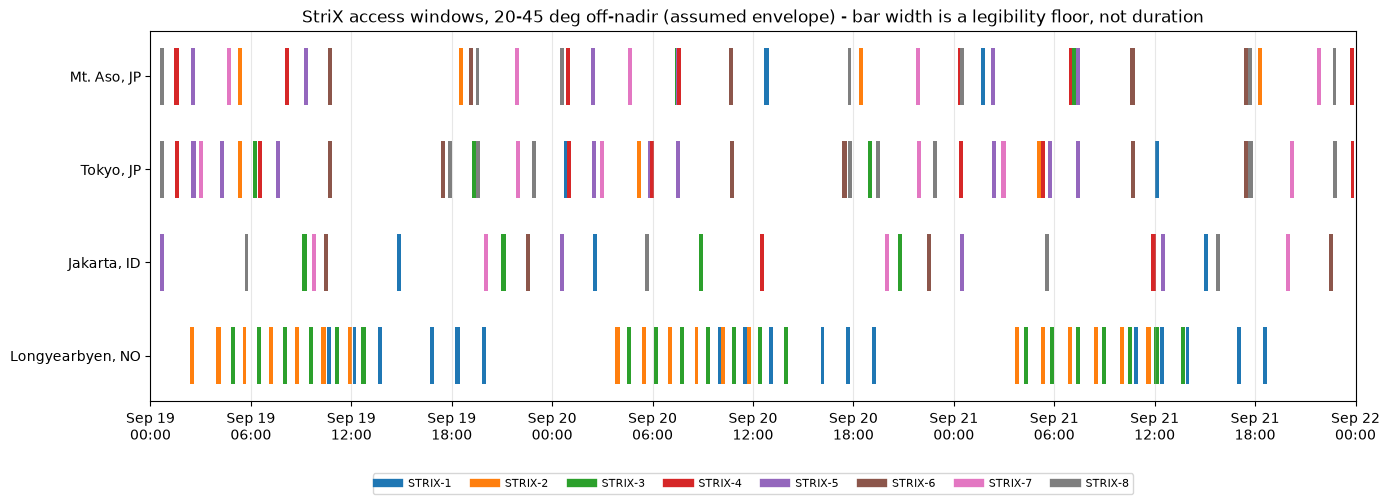

In [6]:
fig, ax = plt.subplots(figsize=(14, 5.2))
order = list(TARGETS)
colors = {n: plt.cm.tab10(i) for i, n in enumerate(sorted(TLES))}

# A window lasts about 85 s on a 3-day axis - under a pixel. Bars are drawn at a floor
# width so they stay visible; real durations are in the table above, not in the bar length.
MIN_BAR_DAYS = 14 / 1440

for _, w in win.iterrows():
    y = order.index(w['target'])
    ax.barh(y, max((w['end'] - w['start']).total_seconds() / 86400, MIN_BAR_DAYS),
            left=mdates.date2num(w['start']), height=.62,
            color=colors[w['satellite']], edgecolor='none')

ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.set_xlim(mdates.date2num(T0), mdates.date2num(T0 + timedelta(days=HORIZON_DAYS)))
ax.set_title(f'StriX access windows, {OFF_NADIR_MIN:.0f}-{OFF_NADIR_MAX:.0f} deg off-nadir '
             f'(assumed envelope) - bar width is a legibility floor, not duration')
ax.grid(axis='x', alpha=.3)
ax.legend(handles=[plt.Line2D([], [], lw=6, color=c, label=n) for n, c in colors.items()],
          fontsize=8, ncol=8, loc='upper center', bbox_to_anchor=(.5, -.18))
fig.tight_layout()

## 5. Why this is the backend's hot path

The shape of the work is worth naming, because it decides how the Go service is written.

Every one of those evaluations is independent. Satellite A against target B at time T needs
nothing from any other combination. The work is a product of three axes - satellites, targets,
time steps - and it grows fast: a constellation of 30 against a few hundred standing targets over
a week is hundreds of millions of evaluations.

That is a textbook fan-out: a bounded worker pool over the pairs, `errgroup` for cancellation,
and results streamed back as each satellite finishes rather than after all of them do. The
cancellation matters more than it sounds - an operator who adjusts a filter should not leave the
previous sweep running.

In [7]:
pairs = len(TLES) * len(TARGETS)
per_eval_us = elapsed / n_eval * 1e6

scale = pd.DataFrame([
    ('this notebook', len(TLES), len(TARGETS), HORIZON_DAYS, n_eval),
    ('one operator shift', 30, 200, 1, 30 * 200 * 86400 / COARSE_STEP_S),
    ('a week of planning', 30, 500, 7, 30 * 500 * 7 * 86400 / COARSE_STEP_S),
], columns=['case', 'satellites', 'targets', 'days', 'evaluations'])
scale['projected (s)'] = (scale.evaluations * per_eval_us / 1e6).round(1)
scale['evaluations'] = scale.evaluations.map(lambda v: f'{v:,.0f}')

print(f'{pairs} satellite-target pairs, {per_eval_us:.2f} us per evaluation (vectorised numpy)')
scale.set_index('case')

32 satellite-target pairs, 8.05 us per evaluation (vectorised numpy)


,satellites,targets,days,evaluations,projected (s)
case,,,,,
this notebook,8,4,3.0,"414,752",3.3
one operator shift,30,200,1.0,"25,920,000",208.5
a week of planning,30,500,7.0,"453,600,000",3649.6


The projection is indicative, not a benchmark - it assumes the per-evaluation cost holds as the
problem grows, which vectorised numpy makes roughly true and a naive Go loop would not. The point
is the order of magnitude: single-threaded, the realistic cases run into minutes, which is too
slow for an interface someone is adjusting filters in. Concurrency is the fix, and the axes to
split on are obvious from the table.

## 6. Fixtures for Go

Everything here derives from public Celestrak TLEs, published algorithms and target coordinates
we chose, so unlike the precise ephemeris in notebook 03 this fixture carries no Synspective
data and is committed to the repository.

It records the assumed constraint alongside the results. That matters: if someone changes the
off-nadir envelope, these expected windows are no longer valid, and the fixture should say so
rather than leaving a Go test failing for reasons nobody can reconstruct.

In [8]:
fixture = {
    'generated_by': 'notebooks/04-access-windows.ipynb',
    'source': 'Celestrak TLEs (public, see fixtures/tle_strix.txt) + chosen target coordinates',
    'assumptions': {
        'off_nadir_min_deg': OFF_NADIR_MIN,
        'off_nadir_max_deg': OFF_NADIR_MAX,
        'note': ('Steering envelope is ASSUMED. The SAR Data Product Format Manual is a file '
                 'format spec and does not publish it. Observed value in the StriX-3 sample '
                 f'product: {OBSERVED_OFF_NADIR} deg.'),
        'earth_model': 'WGS84 ellipsoid, target height 0 m',
        'frame': 'SGP4 TEME rotated to ECEF by IAU-1982 GMST; ECEF velocity excludes omega x r',
    },
    'horizon': {'start_utc': T0.isoformat().replace('+00:00', 'Z'),
                'days': HORIZON_DAYS, 'coarse_step_s': COARSE_STEP_S,
                'edge_refinement': 'bisection, 30 iterations'},
    'targets': {k: {'lat_deg': v[0], 'lon_deg': v[1]} for k, v in TARGETS.items()},
    'windows': [{'satellite': w.satellite, 'target': w.target,
                 'start_utc': w.start.isoformat().replace('+00:00', 'Z'),
                 'end_utc': w.end.isoformat().replace('+00:00', 'Z'),
                 'duration_s': round(w._8, 3),
                 'best_off_nadir_deg': round(w._5, 4),
                 'look_side': w.side, 'pass_direction': w._7}
                for w in win.itertuples()],
}

out = FIXTURES / 'access_windows.json'
out.write_text(json.dumps(fixture, indent=2))
print(f'{out.relative_to(ROOT)}  {out.stat().st_size / 1024:.1f} KB, {len(win)} windows')
print('\nA Go implementation is correct when it reproduces every start and end '
      'to within a second.')

fixtures\access_windows.json  67.8 KB, 219 windows

A Go implementation is correct when it reproduces every start and end to within a second.
